# **Preparación del Entorno**

### **Conectar a Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Importar librerias**

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

### **Cargar el dataset**

In [26]:
ruta_archivo = '/content/drive/MyDrive/data/Proyecto IA/Covid_Procesado_Final.csv'
try:
    df = pd.read_csv(ruta_archivo)
    print("Archivo cargado exitosamente.")
except FileNotFoundError:
    print("No se encontró el archivo")

Archivo cargado exitosamente.


# **Preprocesamiento de datos**

A. Eliminar columnas que no sirven para predecir (ID y Fechas)

In [27]:
# 'DATE_DIED' y 'MONTH_DIED' se eliminan porque "soplan" la respuesta (Data Leakage)
cols_a_eliminar = ['id', 'DATE_DIED', 'MONTH_DIED']
# Solo eliminamos si existen en el archivo
df_clean = df.drop(columns=[c for c in cols_a_eliminar if c in df.columns])

B. Convertir 't' y 'f' de Weka a 1 y 0

In [28]:
# Buscamos columnas de texto y reemplazamos t->1, f->0
for col in df_clean.select_dtypes(include=['object']).columns:
    unique_vals = df_clean[col].astype(str).unique()
    if 't' in unique_vals or 'f' in unique_vals:
        df_clean[col] = df_clean[col].map({'t': 1, 'f': 0})
        df_clean[col] = df_clean[col].fillna(0).astype(int)

C. Separar las características (X) de la etiqueta a predecir (y)

In [29]:
target_col = 'IS_DEAD'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"\nDatos listos para usar.")
print(f"Total de registros: {len(df_clean)}")
print(f"Distribución de la clase objetivo:\n{y.value_counts()}")


Datos listos para usar.
Total de registros: 153884
Distribución de la clase objetivo:
IS_DEAD
-1    76942
 0    76942
Name: count, dtype: int64


# **Primera Ejecución**

Utilizar una división de 80% para entrenamiento y 20% para prueba.

### **EJECUCIÓN 1: DIVISIÓN 80/20 (Académica)**

1. Dividir los datos (80% Train, 20% Test)

In [30]:
# random_state=42 asegura que siempre salga el mismo resultado (reproducible)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.20, random_state=42)

2. Crear y Entrenar el Modelo (Random Forest)

In [31]:
modelo_v1 = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_v1.fit(X_train_80, y_train_80)

RandomForestClassifier(random_state=42)

3. Evaluar

In [32]:
predicciones_20 = modelo_v1.predict(X_test_20)
accuracy_80 = accuracy_score(y_test_20, predicciones_20)

print(f"Registros de Entrenamiento: {len(X_train_80)}")
print(f"Registros de Prueba: {len(X_test_20)}")
print(f"Exactitud (Accuracy) del modelo: {accuracy_80:.4f} ({accuracy_80*100:.2f}%)")

Registros de Entrenamiento: 123107
Registros de Prueba: 30777
Exactitud (Accuracy) del modelo: 0.8988 (89.88%)


# **Segunda Ejecución**

Utilizar una división 50%/50% entre entrenamiento y prueba... análisis equilibrado.

### **EJECUCIÓN 2: DIVISIÓN 50/50 (Investigación Robusta)**

1. Dividir los datos (50% Train, 50% Test)

In [33]:
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(X, y, test_size=0.50, random_state=42)

2. Entrenar Modelo

In [34]:
modelo_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_v2.fit(X_train_50, y_train_50)

RandomForestClassifier(random_state=42)

3. Evaluar

In [35]:
predicciones_50 = modelo_v2.predict(X_test_50)
accuracy_50 = accuracy_score(y_test_50, predicciones_50)

print(f"Registros de Entrenamiento: {len(X_train_50)}")
print(f"Registros de Prueba: {len(X_test_50)}")
print(f"Exactitud (Accuracy) del modelo: {accuracy_50:.4f} ({accuracy_50*100:.2f}%)")

Registros de Entrenamiento: 76942
Registros de Prueba: 76942
Exactitud (Accuracy) del modelo: 0.8971 (89.71%)


## **Evaluación con Múltiples Asignaciones**

Realizar al menos 100 asignaciones aleatorias... calcular la mediana de la confiabilidad.

### **EJECUCIÓN 3: 100 ASIGNACIONES ALEATORIAS (Estabilidad)**

In [36]:
iteraciones = 100
resultados_accuracy = []

print(f"Iniciando {iteraciones} iteraciones... Por favor espera.")

Iniciando 100 iteraciones... Por favor espera.


In [37]:
for i in range(iteraciones):
    # En cada vuelta del bucle, hacemos un split diferente (sin random_state fijo)
    # Usamos 80/20 como base para estas pruebas
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(X, y, test_size=0.20)

    # Entrenamos un modelo rápido
    clf = RandomForestClassifier(n_estimators=50)
    clf.fit(X_train_loop, y_train_loop)

    # Guardamos el resultado
    acc = clf.score(X_test_loop, y_test_loop)
    resultados_accuracy.append(acc)

Convertimos a numpy para calcular estadísticas

In [38]:
resultados_np = np.array(resultados_accuracy)
mediana = np.median(resultados_np)
promedio = np.mean(resultados_np)
minimo = np.min(resultados_np)
maximo = np.max(resultados_np)

print(f"\n--- RESULTADOS FINAL DE ESTABILIDAD ---")
print(f"Mediana de Confiabilidad: {mediana:.4f} ({mediana*100:.2f}%)")
print(f"Promedio: {promedio:.4f}")
print(f"Rango de variación: De {minimo:.4f} a {maximo:.4f}")


--- RESULTADOS FINAL DE ESTABILIDAD ---
Mediana de Confiabilidad: 0.8988 (89.88%)
Promedio: 0.8988
Rango de variación: De 0.8951 a 0.9021


## **Analisis Grafico**

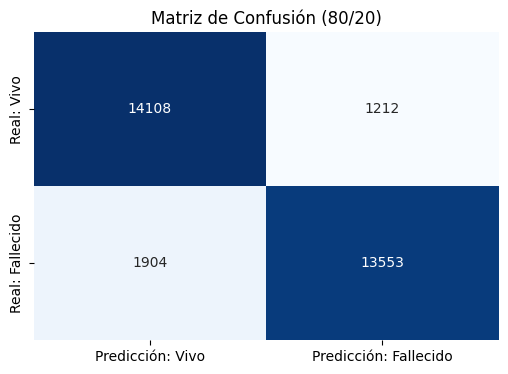

In [39]:
# Generar la matriz
cm = confusion_matrix(y_test_20, predicciones_20)

# Graficar
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicción: Vivo', 'Predicción: Fallecido'],
            yticklabels=['Real: Vivo', 'Real: Fallecido'])
plt.title('Matriz de Confusión (80/20)')
plt.show()